In [1]:
import numpy
import pandas
import uproot

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('mystyle.mplstyle')

import sbruceana

In [18]:
PATH_TO_SBRUCE = "/Users/triozzi/Analysis/nuedis/checks/data/"

FILE_CV = "CNAF_CV_1eNp0pi_NuMI.root"
FILE_VAR1 = "CNAF_CV_1eNp0pi_NuMI_var1.root"
FILE_VAR2 = "CNAF_CV_1eNp0pi_NuMI_var2.root"

FILE_NUE_CV = "CNAF_NuE_1eNp0pi_NuMI_2100.root"
FILE_NUE_VAR2 = "CNAF_NuE_1eNp0pi_NuMI_2100_var2.root"
FILE_NUE_VAR3 = "CNAF_NuE_1eNp0pi_NuMI_2100_var3.root"
FILE_NUE_VAR4 = "CNAF_NuE_1eNp0pi_NuMI_2100_var4.root"
DET_VARS = {
  'CV': FILE_NUE_CV,
  'hi int noise': FILE_NUE_VAR2,
  'recomb': FILE_NUE_VAR3,
  'diff': FILE_NUE_VAR4,
}

BINNING = numpy.array([0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1., 1.1, 1.2, 1.3, 1.4, 1.5, 2, 3])

#### CV

In [17]:
f = sbruceana.io.get_root_file(f"{PATH_TO_SBRUCE}{FILE_CV}")
sbruceana.io.dump_sbruce_keys(f"{PATH_TO_SBRUCE}{FILE_CV}")

['events;1', 'events/POT;4', 'events/POT;3', 'events/POT;2', 'events/POT;1', 'events/Livetime;4', 'events/Livetime;3', 'events/Livetime;2', 'events/Livetime;1', 'events/selectedNu;1', 'events/selectedCos;1', 'events/multisigmaTree;1', 'events/multisimTree;1']


In [8]:
df_cv = sbruceana.io.convert_tree_to_df(
    f"{PATH_TO_SBRUCE}{FILE_CV}",
    "events/selectedNu"
)
pot_cv = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_CV}")
print('CV:', pot_cv)

# high coherent noise
df_var1 = sbruceana.io.convert_tree_to_df(
    f"{PATH_TO_SBRUCE}{FILE_VAR1}",
    "events/selectedNu"
)
pot_var1 = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_VAR1}")
print('high coherent noise:', pot_var1)
print('ratio to CV:', pot_cv / pot_var1)

# high intrinsic noise
df_var2 = sbruceana.io.convert_tree_to_df(
    f"{PATH_TO_SBRUCE}{FILE_VAR2}",
    "events/selectedNu"
)
pot_var2 = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_VAR2}")
print('high intrinsic noise:', pot_var2)
print('ratio to CV:', pot_cv / pot_var2)

CV: 1.5610704077910547e+20
high coherent noise: 1.550678387814522e+20
ratio to CV: 1.0067015959325898
high intrinsic noise: 1.5554025248642617e+20
ratio to CV: 1.003643997509447


In [11]:
df_cv_common, df_var1_common = sbruceana.io.get_dfs_overlap(df_cv, df_var1, 'trueE', True)
_, df_var2_common = sbruceana.io.get_dfs_overlap(df_cv, df_var2, 'trueE', True)

In [12]:
df_cv_not_common, df_var1_not_common = sbruceana.io.get_dfs_overlap(df_cv, df_var1, 'trueE', False)
_, df_var2_not_common = sbruceana.io.get_dfs_overlap(df_cv, df_var2, 'trueE', False)

In [13]:
df_var1_not_common

,trueE,trueL,truePDG,CC,index,recoE,Run,Subrun,Evt,Slice
2,1.101315,661.312134,-12.0,1.0,0.0,0.536240,1013,0,25,2
3,0.807871,781.978516,12.0,1.0,0.0,0.602769,1015,0,34,8
13,1.309168,801.045532,12.0,1.0,0.0,0.945436,109,0,35,1
15,1.562477,714.076538,12.0,1.0,0.0,0.568853,1108,0,9,2
17,0.975989,740.747070,12.0,1.0,1.0,0.472564,1141,0,10,8
...,...,...,...,...,...,...,...,...,...,...
658,1.828312,686.714722,12.0,1.0,0.0,1.294331,748,0,21,1
659,1.165264,774.179688,12.0,1.0,0.0,0.572209,753,0,13,1
660,2.191108,799.872620,14.0,0.0,0.0,0.561124,777,0,26,4
661,3.082155,743.498596,14.0,0.0,0.0,1.469340,789,0,13,8


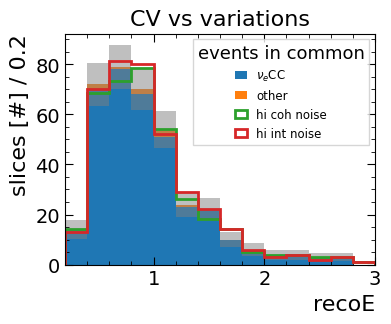

In [15]:
fig, ax = plt.subplots(figsize=(4,3))

var = "recoE"

width = 0.2; bins = numpy.arange(0.2, 3+width, width)

ax = sbruceana.plotting.plot_var_by_category(ax, df_cv_common, bins, var)

ax = sbruceana.plotting.plot_var(ax, df_var1_common, bins, var, 'hi coh noise', pot_cv / pot_var1)
ax = sbruceana.plotting.plot_var(ax, df_var2_common, bins, var, 'hi int noise', pot_cv / pot_var2)

# gfx
ax.set_xlim(bins[0], bins[-1])
ax.set_title('CV vs variations', fontsize=16)
ax.set_xlabel(var, loc='right', fontsize=16)
ax.set_ylabel(f'slices [#] / {width}', loc='top', fontsize=16)
leg = ax.legend(loc='best', fancybox=False, handlelength=1, title='events in common'); leg.get_title().set_fontsize(13)
ax.tick_params(which='major', length=6, direction='in', labelsize=14, right=True, top=True)
ax.minorticks_on()
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)

plt.show()

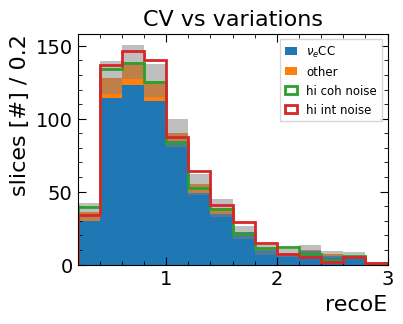

In [16]:
fig, ax = plt.subplots(figsize=(4,3))

var = "recoE"

width = 0.2; bins = numpy.arange(0.2, 3+width, width)

ax = sbruceana.plotting.plot_var_by_category(ax, df_cv, bins, var)

ax = sbruceana.plotting.plot_var(ax, df_var1, bins, var, 'hi coh noise', pot_cv / pot_var1)
ax = sbruceana.plotting.plot_var(ax, df_var2, bins, var, 'hi int noise', pot_cv / pot_var2)

# gfx
ax.set_xlim(bins[0], bins[-1])
ax.set_title('CV vs variations', fontsize=16)
ax.set_xlabel(var, loc='right', fontsize=16)
ax.set_ylabel(f'slices [#] / {width}', loc='top', fontsize=16)
ax.legend(loc='best', fancybox=False, handlelength=1)
ax.tick_params(which='major', length=6, direction='in', labelsize=14, right=True, top=True)
ax.minorticks_on()
ax.tick_params(which='minor', length=3, direction='in', right=True, top=True)

plt.show()

#### $\nu_e$-only

In [19]:
dfs, pots, tags = [], [], []

for tag, file in DET_VARS.items():

  # get sbruce tree
  df = sbruceana.io.convert_tree_to_df(
    f"{PATH_TO_SBRUCE}{file}",
    "events/selectedNu"  
  )
  dfs.append(df)

  # get POTs
  pot = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{file}")
  pots.append(pot)

  # get variation tag
  tags.append(tag)

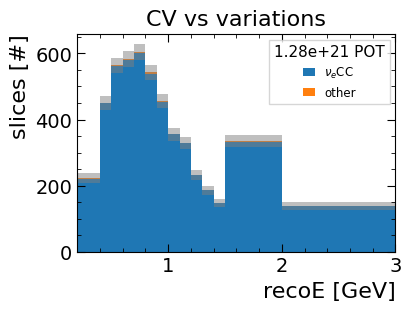

In [23]:
fig, ax = plt.subplots(figsize=(4,3), layout='constrained')

var = "recoE"

# width = 0.2; bins = numpy.arange(0.2, 3+width, width)
bins = BINNING

ax = sbruceana.plotting.plot_var_by_category(ax, dfs[0], bins, var, True)

# gfx
ax.set(
  title  = f'CV vs variations',
  xlabel = f'{var} [GeV]',
  ylabel = 'slices [#]',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(title=f'{pots[0]:.2e} POT'); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig("plots/CNAF_NuE_1eNp0pi_NuMI.png", dpi=300)

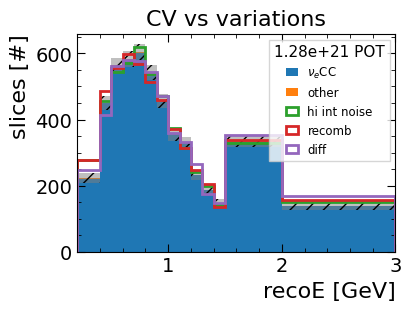

In [26]:
fig, ax = plt.subplots(figsize=(4,3), layout='constrained')

var = "recoE"

# width = 0.2; bins = numpy.arange(0.2, 3+width, width)
bins = BINNING

ax = sbruceana.plotting.plot_var_by_category(ax, dfs[0], bins, var, True, hatch='//')

for df, pot, tag in zip(dfs[1:], pots[1:], tags[1:]):
  ax = sbruceana.plotting.plot_var(ax, df, bins, var, tag, pots[0] / pot)

# gfx
ax.set(
  title  = f'CV vs variations',
  xlabel = f'{var} [GeV]',
  ylabel = 'slices [#]',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(title=f'{pots[0]:.2e} POT'); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig("plots/CNAF_NuE_1eNp0pi_NuMI_DetVars.png", dpi=300)

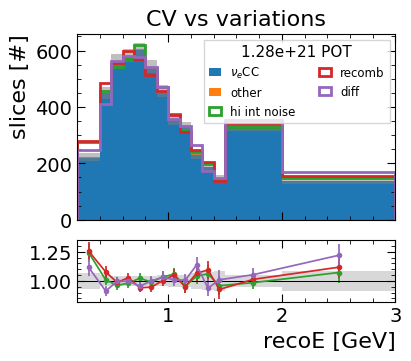

In [27]:
fig, (ax, ax_ratio) = plt.subplots(
  2, 1,
  figsize     = (4, 3.5),
  gridspec_kw = {
    'height_ratios': [3, 1], 
    'hspace': 0.03
  },
  sharex      = True,
  layout      = 'constrained'
)

var = "recoE"

bins = BINNING
x = 0.5 * (bins[:-1] + bins[1:])

# CV
ax = sbruceana.plotting.plot_var_by_category(ax, dfs[0], bins, var)

# variations
i = 0
for df, pot, tag in zip(dfs[1:], pots[1:], tags[1:]):
  ax = sbruceana.plotting.plot_var(ax, df, bins, var, tag, pots[0] / pot)

  # residuals
  r, er = sbruceana.utils.get_ratio_of_vars(dfs[0][var], pots[0], df[var], pot, bins)
  ax_ratio.errorbar(x, r, yerr=er, fmt=f'C{i+2}', marker='.', markersize=6, linewidth=1.25)
  i += 1

# references
ax_ratio.axhline(1, c='black', lw=0.75)
cv,  _ = numpy.histogram(dfs[0][var], bins=bins)
cv_err_ratio = numpy.where(cv > 0, numpy.sqrt(cv) / cv, numpy.nan)
ax_ratio.bar(x, 2*cv_err_ratio, width = numpy.diff(bins), bottom = 1-cv_err_ratio, color='gray', alpha=0.3, fill=True, lw=0)

# gfx
ax.set(
  title  = f'CV vs variations',
  ylabel = 'slices [#]',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(ncols=2, loc='upper right', title=f'{pots[0]:.2e} POT'); leg.get_title().set_fontsize(11)
ax_ratio.set(
  xlabel = f'{var} [GeV]',
)

fig.savefig("plots/CNAF_NuE_1eNp0pi_NuMI_DetVars_WithRes.png", dpi=300)